In [9]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

sns.set(style='whitegrid')

In [10]:
repo_root = Path('/playpen-ssd/wokwen/projects/autoeval_chatbot')
data_path = repo_root / 'ratings' / 'gpt' / 'overall' / 'overall_ratings.csv'

df = pd.read_csv(data_path, on_bad_lines='skip')
print('Shape:', df.shape)
df.head()

Shape: (500, 10)


,conversation_id,user_rating,self_rating,observer_rating,total_turns,avg_user_length,avg_bot_length,primary_language,error_rate,error_count
0,conv_000,9.0,8.5,8.5,30,100.13,667.90,Dutch,0.533,16
1,conv_001,9.0,8.5,8.5,30,96.13,675.60,English,0.533,16
2,conv_002,8.5,8.5,8.5,30,96.83,680.87,English,0.533,16
3,conv_003,9.0,8.5,8.5,30,96.57,633.43,Portuguese,0.533,16
4,conv_004,9.0,9.0,8.5,30,93.27,604.93,Spanish,0.533,16


In [11]:
# Summary statistics
summary = df[['user_rating', 'observer_rating', 'self_rating']].describe()
display(summary)

,user_rating,observer_rating,self_rating
count,500.000000,500.000000,500.000000
mean,8.980000,8.667000,8.728000
std,0.098078,0.250472,0.255238
min,8.500000,7.500000,7.500000
25%,9.000000,8.500000,8.500000
50%,9.000000,8.500000,8.500000
75%,9.000000,9.000000,9.000000
max,9.000000,9.500000,9.000000


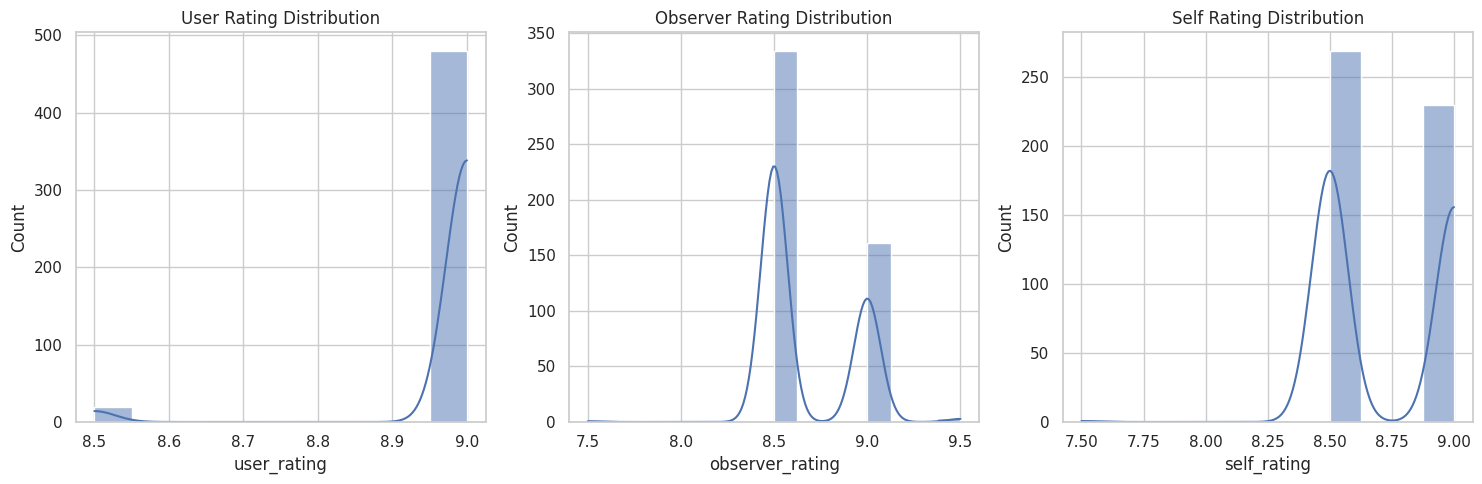

In [13]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['user_rating'], ax=axes[0], kde=True)
axes[0].set_title('User Rating Distribution')
sns.histplot(df['observer_rating'], ax=axes[1], kde=True)
axes[1].set_title('Observer Rating Distribution')
sns.histplot(df['self_rating'], ax=axes[2], kde=True)
axes[2].set_title('Self Rating Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# Correlation analysis
numeric_cols = ['User_Rating', 'Observer_Rating', 'Self_Rating']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Statistical tests: compare means
results = []
for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i < j:
            group1 = df[col1].dropna()
            group2 = df[col2].dropna()
            if len(group1) > 1 and len(group2) > 1:
                t_stat, p_val = ttest_ind(group1, group2)
                results.append({
                    'comparison': f'{col1} vs {col2}',
                    'mean1': group1.mean(),
                    'mean2': group2.mean(),
                    't_stat': t_stat,
                    'p_value': p_val,
                    'significant': p_val < 0.05
                })
results_df = pd.DataFrame(results)
display(results_df)